In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.utils.data

from tqdm import trange

torch.manual_seed(42)
np.random.seed(42)

In [2]:
LR = 0.1
EPOCH = 1000
BS = 128 
PERCENTAGE_TEST = 0.2

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
# Data preparation
modes = df.mode().iloc[0]
df.fillna(modes, inplace=True) # fix missing values
df["Fare"] = np.log1p(df["Fare"])
df["Sex"] = (df["Sex"] == "male").astype(int)
df = pd.get_dummies(df, columns=["Pclass", "Embarked"], drop_first=True)
x_cols = ["Sex", "Age", "SibSp", "Parch", "Fare", 
          "Pclass_2", "Pclass_3", "Embarked_Q", "Embarked_S"]

## Pytorch

In [5]:
# normalizing the dataset
x = torch.tensor(df[x_cols].values, dtype=torch.float32)
max_v, _ = x.max(dim=0)
x = x / max_v
y = torch.tensor(df["Survived"], dtype=torch.float32)

In [6]:
# splitting the dataset
N = x.shape[0]
perm = torch.randperm(N)
x, y = x[perm], y[perm].reshape(-1, 1)
n_test = int(N * PERCENTAGE_TEST)
x_train, x_test = x[n_test:], x[:n_test]
y_train, y_test = y[n_test:], y[:n_test]

In [7]:
import torch.nn as nn
class LinModel(nn.Module):
  def __init__(self, in_features):
    super().__init__()
    self.lin = nn.Sequential(
      nn.Linear(in_features, 1, bias=False),
      nn.Sigmoid(),
    )
  
  def forward(self, x):
    return self.lin(x)

In [8]:
model = LinModel(x_train.shape[1])
loss_function = nn.MSELoss()
optim = torch.optim.SGD(model.parameters(), lr=LR)

losses, accuracies = [], []
for t in trange(EPOCH):
  # batch selection
  batch = torch.randint(len(x_train), (BS, ))
  x, y = x_train[batch], y_train[batch]

  # forward pass
  preds = model(x)
  acc = ((preds >= 0.5) == y).float().mean()

  # backward pass
  loss = loss_function(preds, y)
  loss.backward()

  # gradient descent + zero grad
  optim.step()
  optim.zero_grad()

  losses.append(loss.item())
  accuracies.append(acc)

100%|██████████| 1000/1000 [00:00<00:00, 8053.02it/s]


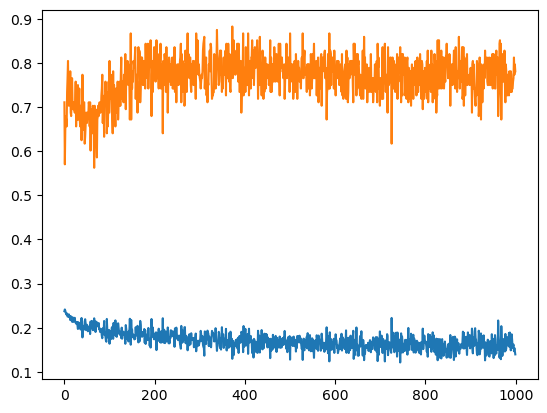

In [9]:
plt.plot(losses)
plt.plot(accuracies)

In [10]:
acc = ((model(x_test) >= 0.5) == y_test).float().mean()
print(f"accuracy: {acc*100:.4f}")

accuracy: 79.2135


## Numpy + Pandas only

In [11]:
# normalizing the dataset
x = np.array(df[x_cols].values, dtype=np.float32)
max_v = x.max(axis=0)
x = x / max_v
y = np.array(df["Survived"])

In [12]:
# splitting the dataset
N = x.shape[0]
perm = np.random.permutation(N)
x, y = x[perm], y[perm]
n_test = int(N * PERCENTAGE_TEST)
x_train, x_test = x[n_test:], x[:n_test]
y_train, y_test = y[n_test:], y[:n_test]

In [13]:
class LinModel:
  def __init__(self, n_feature):
    self.layer = np.random.rand(n_feature) / n_feature

  @staticmethod
  def sigmoid(x): 
    return 1 / (1 + np.exp(-x))
  
  def forward(self, x):
    x = x.dot(self.layer)
    return self.sigmoid(x)

  def get_gradients(self, x, y): 
    return 2 * x.T.dot(self.forward(x) - y) / x.shape[0]

In [14]:
model = LinModel(x_train.shape[1])

losses, accuracies = [], []
for _ in (t := trange(EPOCH)):
  # batch sampling
  batch = np.random.randint(len(x_train), size=BS)
  x, y = x_train[batch], y_train[batch]

  # forward pass
  preds = model.forward(x)
  acc = ((preds >= 0.5) == y).mean()

  # backward pass
  loss = ((preds - y)**2).mean()
  model.layer -= LR * model.get_gradients(x, y)

  losses.append(loss)
  accuracies.append(acc)

100%|██████████| 1000/1000 [00:00<00:00, 35148.49it/s]


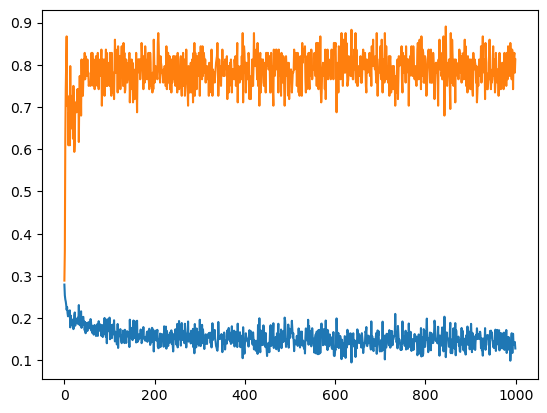

In [15]:
plt.plot(losses)
plt.plot(accuracies)

In [16]:
acc = ((model.forward(x_test) >= 0.5) == y_test).mean()
print(f"accuracy: {acc*100:.4f}")

accuracy: 77.5281
